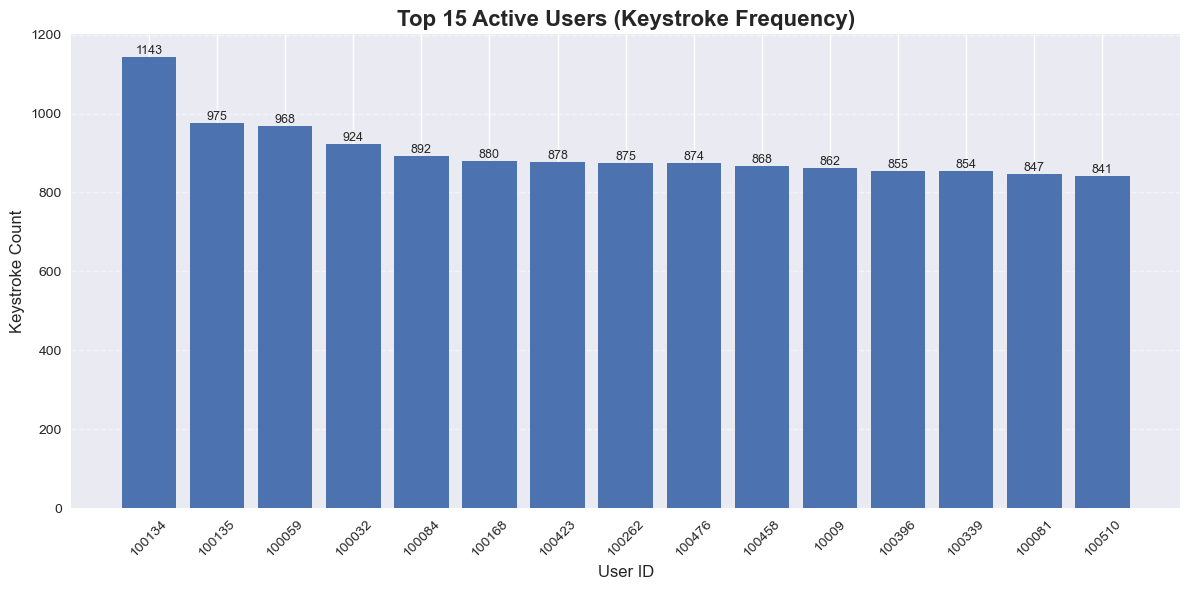

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.facecolor'] = 'white'

plt.style.use('seaborn-v0_8')

df = pd.read_csv("../data/keystroke_data.csv")

user_counts = df["PARTICIPANT_ID"].value_counts().head(15)

plt.figure(figsize=(12,6))

bars = plt.bar(user_counts.index.astype(str), user_counts.values)

plt.title("Top 15 Active Users (Keystroke Frequency)", fontsize=16, fontweight='bold')
plt.xlabel("User ID", fontsize=12)
plt.ylabel("Keystroke Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=45)

# Add values on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             int(bar.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../results/user_distribution.png", dpi=300)
plt.show()

In [21]:
models = ["Random Forest", "XGBoost", "LSTM", "Transformer"]
accuracy = [0.365, 0.429, 0.851, 0.951]

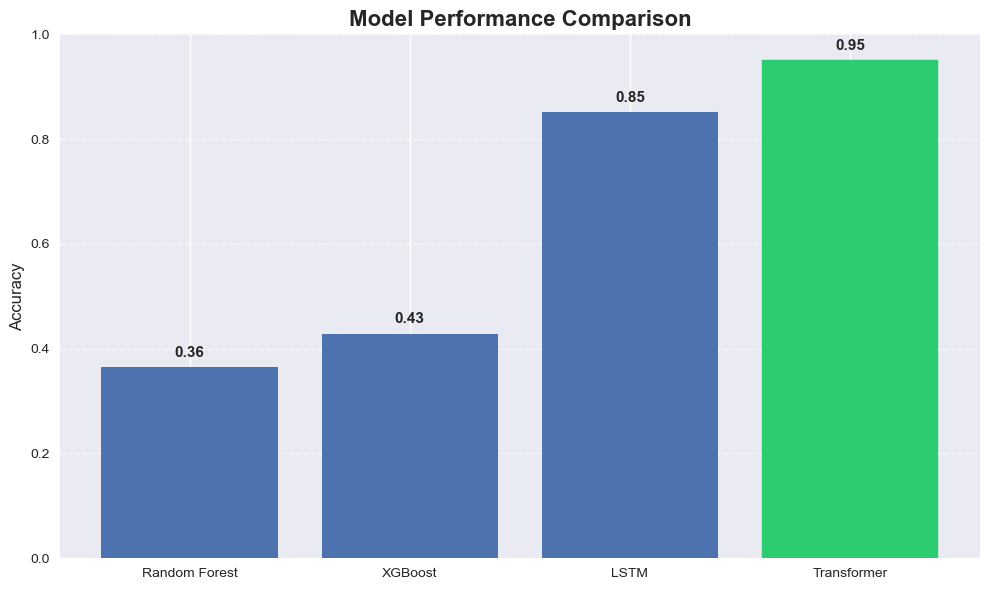

In [22]:
plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracy)

plt.title("Model Performance Comparison", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12)

plt.ylim(0,1)

# Highlight best model
bars[-1].set_color('#2ecc71')

# Add labels
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("../results/comparison_chart.png", dpi=300)
plt.show()

In [23]:
import torch
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, num_heads, num_layers, num_classes):
        super().__init__()
        
        self.input_fc = nn.Linear(input_size, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        self.fc = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x

In [24]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/keystroke_data.csv")

df = df.sort_values(by=["PARTICIPANT_ID", "PRESS_TIME"])

df["hold_time"] = df["RELEASE_TIME"] - df["PRESS_TIME"]
df["next_press"] = df.groupby("PARTICIPANT_ID")["PRESS_TIME"].shift(-1)
df["flight_time"] = df["next_press"] - df["RELEASE_TIME"]

df = df.dropna()
df = df[(df["hold_time"] > 0) & (df["flight_time"] > 0)]

top_users = df["PARTICIPANT_ID"].value_counts().head(50).index
df = df[df["PARTICIPANT_ID"].isin(top_users)]

# sequences
sequence_length = 30
sequences, labels = [], []

for user in df["PARTICIPANT_ID"].unique():
    user_df = df[df["PARTICIPANT_ID"] == user]
    data = user_df[["hold_time", "flight_time"]].values

    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i+sequence_length])
        labels.append(user)

import numpy as np
X = np.array(sequences)
y = np.array(labels)

# scaling
num_samples, seq_len, num_features = X.shape
X = X.reshape(-1, num_features)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X.reshape(num_samples, seq_len, num_features)

# encode
le = LabelEncoder()
y = le.fit_transform(y)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# convert to tensor
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [25]:
model = TransformerModel(input_size=2, d_model=64, num_heads=4, num_layers=2, num_classes=50)

model.load_state_dict(torch.load("../models/transformer_model.pth"))
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, pred = torch.max(outputs, 1)

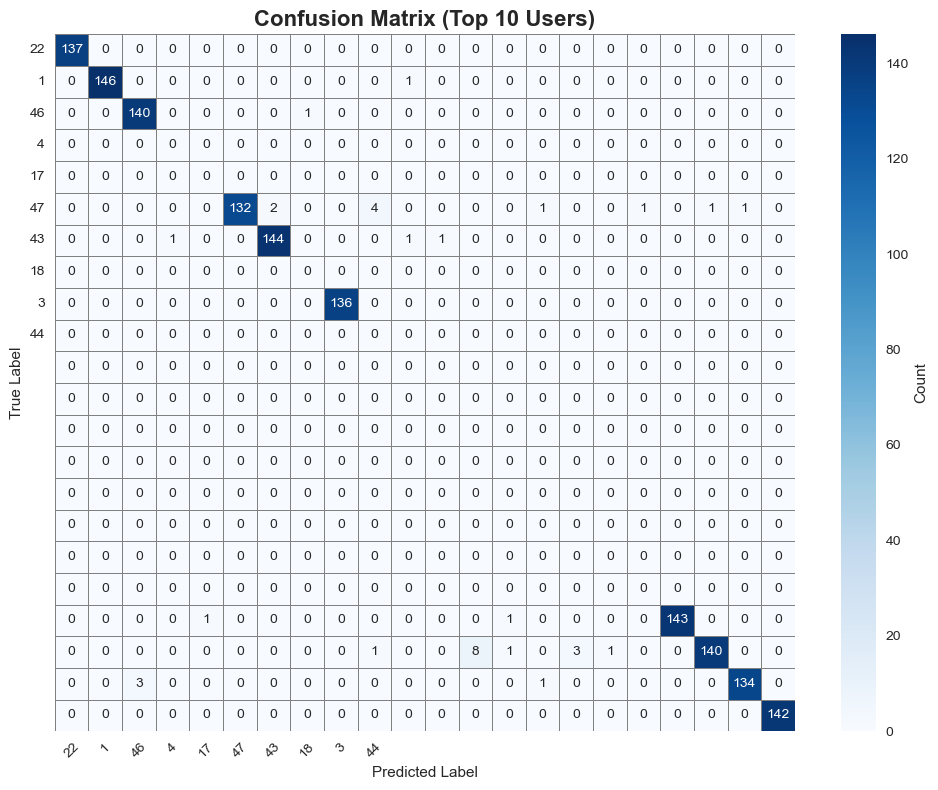

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Convert tensors
y_true = y_test.numpy()
y_pred = pred.numpy()

# Get top 10 most frequent classes
unique, counts = np.unique(y_true, return_counts=True)
top_classes = unique[np.argsort(counts)[-10:]]

# Filter only top classes
mask = np.isin(y_true, top_classes)

y_true_top = y_true[mask]
y_pred_top = y_pred[mask]

cm = confusion_matrix(y_true_top, y_pred_top)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=top_classes,
            yticklabels=top_classes,
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Count'})

plt.title("Confusion Matrix (Top 10 Users)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()